# Photonic Quantum Kernel (Havlíček-inspired): Deeper Circuit implementation

This notebook implements a photonic analogue of the quantum kernel
introduced in Havlíček et al. (2019).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### Part 02: Double-Layer Kernel

In order to increase expressivity in feature map we add one more phase shifting layer.

We define the new photonic feature map:

U(x) = B * Φ_2(x) * B * Φ_1(x) * B

where B is a beam splitter and Φ_1(x), Φ_2(x) encodes classical data as phases.

Kernel Matrix:
 [[1.         0.5        0.43529524]
 [0.5        1.         0.98296291]
 [0.43529524 0.98296291 1.        ]]
Diagonals: [1. 1. 1.]
Symmetric: True


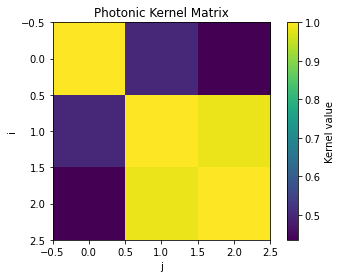

In [10]:
#Deepening the kernel

#Beam splitter
B = np.array([[1, 1j],
             [1j, 1]], dtype=complex) /np.sqrt(2)

#phase encoding matrix- two layers
def phi1(x1, x2):
    return np.array([[np.exp(1j * x1), 0],
                    [0, np.exp(1j * x2)]], dtype=complex)
def phi2(x1, x2):
    return np.array([[np.exp(1j * (x1 + x2)), 0],
                    [0, np.exp(1j * (x1 - x2))]], dtype=complex)

#Feature-map unitary
def unitary(x1, x2):
    return B @ phi2(x1, x2) @ B @ phi1(x1, x2) @ B

#input state |1,0> as a column vector
psi_in = np.array([1, 0], dtype=complex)

#output state |phi(x)>
def state(x):
    x1, x2 = x
    return unitary(x1, x2) @ psi_in
                    
#Kernel value K(x, x')
def photonic_kernel(x, xp):
    psi_x = state(x)
    psi_xp = state(xp)
    overlap = np.vdot(psi_x, psi_xp) #inner product of psi_x and psi_xp
    return np.abs(overlap)**2

#kernel matrix
def photonic_kernel_matrix(X):
    n = len(X)
    K = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            K[i,j] = photonic_kernel(X[i], X[j])
    return K

# Example data points
X = np.array([
    [np.pi/2, np.pi],
    [0, 0],
    [np.pi/4, np.pi/3]
])

K = photonic_kernel_matrix(X)
print("Kernel Matrix:\n",K)
print("Diagonals:", np.diag(K))
print("Symmetric:", np.allclose(K, K.T))

plt.imshow(K)
plt.colorbar(label="Kernel value")
plt.title("Photonic Kernel Matrix")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

NOTE: Deeper feature map gives similar kernel matrix to our first non-phase modified feature map.

Let's see how it performs classification.

[[1.         0.99013262 0.9999751  0.99005818 0.99019875 0.9999915
  0.98454961 0.99930048]
 [0.99013262 1.         0.99025586 0.9999751  0.99948551 0.99019875
  0.99890113 0.98446893]
 [0.9999751  0.99025586 1.         0.99013262 0.99009568 0.99999569
  0.98446893 0.99915849]
 [0.99005818 0.9999751  0.99013262 1.         0.99968334 0.99009568
  0.99912746 0.98446266]
 [0.99019875 0.99948551 0.99009568 0.99968334 1.         0.99013262
  0.99933786 0.98504505]
 [0.9999915  0.99019875 0.99999569 0.99009568 0.99013262 1.
  0.98449348 0.99922644]
 [0.98454961 0.99890113 0.98446893 0.99912746 0.99933786 0.98449348
  1.         0.97816695]
 [0.99930048 0.98446893 0.99915849 0.98446266 0.98504505 0.99922644
  0.97816695 1.        ]]
Diagonals: [1. 1. 1. 1. 1. 1. 1. 1.]
Symmetric: True
Predictions: [1 0]
True labels [0 1]
Accuracy: 0.0


<function matplotlib.pyplot.show(close=None, block=None)>

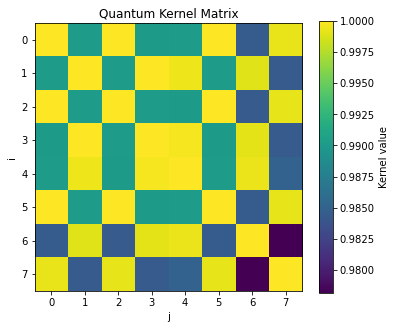

In [4]:
#Sample dataset
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.15, 0.25],
    [0.25, 0.15],
    [1.8, 1.9],
    [1.9, 1.8],
    [1.7, 1.85],
    [1.85, 1.7]
])

y = np.array([0, 0, 0, 0, 1, 1, 1, 1]) #classification -- first 4 classified as 0 and last 4 classified as 1

#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#Kernel matrix between two sets
def kernel_matrix(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = photonic_kernel(A[i], B[j])
    return K

#Build train/test kernel matrices
K_all = photonic_kernel_matrix(X)
print(K_all)
print("Diagonals:", np.diag(K_all))
print("Symmetric:", np.allclose(K_all, K_all.T))

K_train = kernel_matrix(X_train, X_train)
K_test = kernel_matrix(X_test, X_train)

#Classification
clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train)

#predict
y_pred = clf_q.predict(K_test)

print("Predictions:", y_pred)
print("True labels", y_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

#PLot
plt.figure(figsize=(6,5))
plt.imshow(K_all)
plt.colorbar(label="Kernel value")
plt.title("Quantum Kernel Matrix")
plt.xlabel("j")
plt.ylabel("i")
plt.show


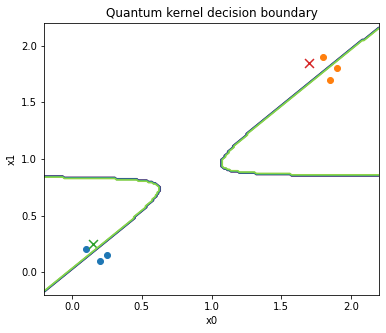

In [11]:
#Desicion boundary

#Creating a grid in input space
x0_min, x0_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x1_min, x1_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 200),
    np.linspace(x1_min, x1_max, 200)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

#Quantum kernel between grid points and training points
K_grid_q = kernel_matrix(grid_points, X_train)

#Predict class of each point
Z_q = clf_q.predict(K_grid_q)
Z_q = Z_q.reshape(xx.shape)

#Plot
plt.figure(figsize=(6,5))
plt.contour(xx, yy, Z_q, alpha=0.8)

for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"train class{label}")
    
for label in np.unique(y_test):
    pts = X_test[y_test == label]
    plt.scatter(pts[:,0], pts[:,1], marker="x", s=80, label=f"test class{label}")
    
plt.title("Quantum kernel decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()


NOTE: In this case deep circuit kernel struggles to classify simple dataset. And we can clearly see from the kernel matrix and decision boundary plot that 

Now let's see how it works on complex data set.

### Complexifying the dataset: two-moons set

Quantum accuracy 0.7
Classical accuracy: 0.95


<function matplotlib.pyplot.show(close=None, block=None)>

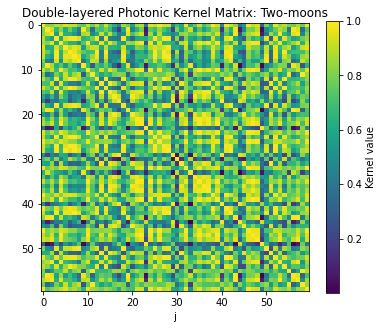

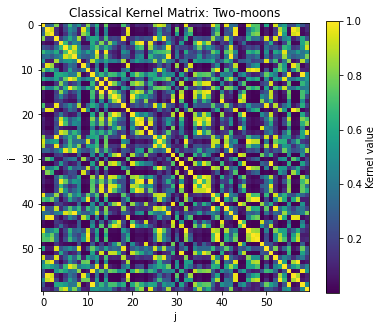

In [22]:
#Import and make dataset
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=80, noise=0.08, random_state=42)

#split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#for quantum kernel I will proceed to use previously defined one
#classical baseline
def classical_rbf_kernel(x1, x2, gamma=1.0):
    return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)

def classical_kernel_matrix(A, B, gamma=1.0):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = classical_rbf_kernel(A[i], B[j], gamma=gamma)
    return K

#Training -- quantum
Kq_train = kernel_matrix(X_train, X_train)
Kq_test = kernel_matrix(X_test, X_train)

clf_q = SVC(kernel="precomputed")
clf_q.fit(Kq_train, y_train)
y_pred_q = clf_q.predict(Kq_test)

print("Quantum accuracy", accuracy_score(y_test, y_pred_q))

#Training -- classical
Kc_train = classical_kernel_matrix(X_train, X_train, gamma=1.0)
Kc_test = classical_kernel_matrix(X_test, X_train, gamma=1.0)

clf_c = SVC(kernel="precomputed")
clf_c.fit(Kc_train, y_train)
y_pred_c = clf_c.predict(Kc_test)

print("Classical accuracy:", accuracy_score(y_test, y_pred_c))

#Visualisation of kernel matrices
plt.figure(figsize=(6,5))
plt.imshow(Kq_train)
plt.colorbar(label="Kernel value")
plt.title("Double-layered Photonic Kernel Matrix: Two-moons")
plt.xlabel("j")
plt.ylabel("i")
plt.savefig("2layer_photonic_kernel_matrix_2moons.png", dpi=300, bbox_inches='tight')
plt.show

plt.figure(figsize=(6,5))
plt.imshow(Kc_train)
plt.colorbar(label="Kernel value")
plt.title("Classical Kernel Matrix: Two-moons")
plt.xlabel("j")
plt.ylabel("i")
plt.savefig("class_kernel_matrix_2moons.png", dpi=300, bbox_inches='tight')
plt.show

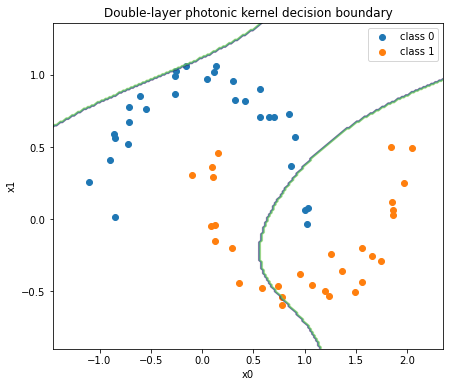

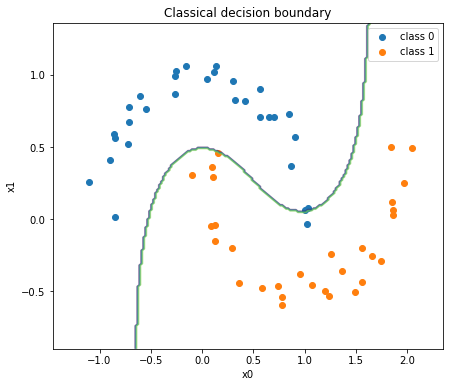

In [14]:
#Decision boundaries of two-moons set

#grid
x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 200),
    np.linspace(x1_min, x1_max, 200)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

#quantum
K_grid_q = kernel_matrix(grid_points, X_train)
Z_q = clf_q.predict(K_grid_q).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z_q, alpha=0.35)
for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"class {label}")
plt.title("Double-layer photonic kernel decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

#Classical
K_grid_c = classical_kernel_matrix(grid_points, X_train)
Z_q = clf_c.predict(K_grid_c).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z_q,alpha=0.35)
for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:, 0], pts[:, 1], label = f"class {label}")
plt.title("Classical decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

NOTE: Even if double-layered circuit badly performs on a simpler data, it shows enhanced labeling accuracy compared to Havlicek type kernel and single layer photonic kernel.

    Quantum accuracy 0.7
    Classical accuracy: 0.95